# Portfolio Optimization - Data Pipeline

Connect to Yahoo Finance, pull 10 years of monthly adjusted-close prices, clean data, and compute returns

### Install & Import Dependencies

In [19]:
# Install required packages (run once)
import sys
#!{sys.executable} -m pip install yfinance seaborn

  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)

[notice] A new release of pip is available: 25.2 -> 26.1.1
[notice] To update, run: /Users/scottkeighley/.venv/bin/python -m pip install --upgrade pip


In [52]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import warnings
import os

warnings.filterwarnings('ignore')

# Plotting
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

print('Libraries loaded successfully')

Libraries loaded successfully


### Define Assets

30 large-cap US equities, diversified

In [26]:
UNIVERSE = {
    'Information Technology': ['AAPL', 'MSFT', 'NVDA'],
    'Financials':             ['JPM', 'BAC', 'GS'], 
    'Health Care':            ['JNJ', 'UNH', 'PFE'],
    'Consumer Discretionary': ['AMZN', 'TSLA', 'HD'],
    'Communication Services': ['GOOGL', 'META', 'VZ'],
    'Industrials':            ['CAT', 'HON', 'UPS'],
    'Consumer Staples':       ['PG', 'KO', 'WMT'],
    'Energy':                 ['XOM', 'CVX', 'SLB'],
    'Utilities':              ['NEE', 'DUK'],
    'Real Estate':            ['PLD', 'AMT'],
    'Materials':              ['LIN', 'SHW']
}

# Flatten to a list
TICKERS = [ticker for tickers in UNIVERSE.values() for ticker in tickers]

# Build a ticker -> sector mapping
TICKER_SECTOR = {
    ticker: sector
    for sector, tickers in UNIVERSE.items()
    for ticker in tickers
}

print(f'Universe: {len(TICKERS)} assets across {len(UNIVERSE)} sectors')
print(f'Tickers: {TICKERS}')

Universe: 30 assets across 11 sectors
Tickers: ['AAPL', 'MSFT', 'NVDA', 'JPM', 'BAC', 'GS', 'JNJ', 'UNH', 'PFE', 'AMZN', 'TSLA', 'HD', 'GOOGL', 'META', 'VZ', 'CAT', 'HON', 'UPS', 'PG', 'KO', 'WMT', 'XOM', 'CVX', 'SLB', 'NEE', 'DUK', 'PLD', 'AMT', 'LIN', 'SHW']


### Set Date Range

In [29]:
END_DATE = pd.Timestamp.today().normalize()
START_DATE = END_DATE - pd.DateOffset(years=10)

print(f'Data window: {START_DATE.date()} -> {END_DATE.date()}')

Data window: 2016-05-16 -> 2026-05-16


### Download Price Data from Yahoo Finance

Pull monthly adjusted-close prices. 

Adjusted close accounts for splits and dividends - for clean return calculations

In [32]:
print('Downloading price data from Yahoo Finance...')

raw = yf.download(
    tickers=TICKERS,
    start=START_DATE,
    end=END_DATE,
    interval='1mo',
    auto_adjust=True,
    progress=True
)

#Extract close column (equals Adj Close when auto_adjust=True)
prices_raw = raw['Close'].copy()

print(f'\nRaw data shape: {prices_raw.shape} ({prices_raw.shape[0]} months x {prices_raw.shape[1]} assets)')
prices_raw.tail()

[*********************100%***********************]  30 of 30 completed


Raw data shape: (120, 30) (120 months x 30 assets)


Ticker,AAPL,AMT,AMZN,BAC,CAT,CVX,DUK,GOOGL,GS,HD,...,PG,PLD,SHW,SLB,TSLA,UNH,UPS,VZ,WMT,XOM
Date,,,,,,,,,,,,,,,,,,,,,
2026-01-01,258.998840,177.506424,239.300003,52.900944,654.579346,175.186264,119.294334,337.762238,930.512939,372.102264,...,149.573730,129.518021,353.857574,48.096375,430.410004,284.716522,104.759079,43.112320,118.669518,139.516785
2026-02-01,263.690094,189.961975,210.000000,49.549889,741.418518,184.950745,128.633423,311.540710,855.070007,378.191559,...,165.950378,141.432175,361.790009,51.039021,402.510010,291.007599,114.365112,49.397030,127.444725,150.468964
2026-03-01,253.556381,170.872711,208.270004,48.475960,707.113831,206.899994,129.818207,287.357727,841.561096,326.705780,...,143.360489,131.125076,319.842743,51.389999,371.750000,268.502563,98.379997,49.456142,123.789223,168.516205
2026-04-01,271.100250,180.902496,265.059998,53.459999,888.418579,193.309998,128.440109,384.799988,923.770020,328.799988,...,145.990677,142.020004,321.609985,56.880001,381.630005,370.480011,108.800003,47.318295,131.678696,153.289551
2026-05-01,300.230011,170.630005,264.140015,49.770000,888.309998,191.100006,120.949997,396.779999,948.469971,297.510010,...,141.570007,140.529999,300.100006,55.380001,422.239990,393.850006,98.930000,46.369999,131.449997,157.919998


### Data Cleaning

Check for missing data, forward-fill short gaps, and drop assets that are missing a lot of info

In [35]:
# === Inspect missing data ===
missing = prices_raw.isnull().sum()
missing_pct = (missing / len(prices_raw) * 100).round(2)

missing_report = pd.DataFrame({'missing_months': missing, 'missing_pct': missing_pct})
missing_report = missing_report[missing_report['missing_months'] > 0].sort_values('missing_pct', ascending=False)

if missing_report.empty: 
    print('No missing data detected - clean universe.')
else: 
    print('Assets with missing data:')
    print(missing_report)

No missing data detected - clean universe.


In [37]:
# === Drop assets mssing more than 5% of history ===
MISSING_THRESHOLD = 0.05
valid_tickers = missing_pct[missing_pct / 100 <= MISSING_THRESHOLD].index.tolist()
dropped = set(TICKERS) - set(valid_tickers)

if dropped: 
    print(f'Dropping assets with >{MISSING_THRESHOLD*100}% missing data: {dropped}')
else: 
    print('No assets dropped.')

prices_raw = prices_raw[valid_tickers]

# === Forward-fill small gaps (e.g. holidays) ===
prices = prices_raw.ffill().dropna()

print(f'\nClean price matrix shape: {prices.shape}')
prices.tail()

No assets dropped.

Clean price matrix shape: (120, 30)


Ticker,AAPL,AMT,AMZN,BAC,CAT,CVX,DUK,GOOGL,GS,HD,...,PG,PLD,SHW,SLB,TSLA,UNH,UPS,VZ,WMT,XOM
Date,,,,,,,,,,,,,,,,,,,,,
2026-01-01,258.998840,177.506424,239.300003,52.900944,654.579346,175.186264,119.294334,337.762238,930.512939,372.102264,...,149.573730,129.518021,353.857574,48.096375,430.410004,284.716522,104.759079,43.112320,118.669518,139.516785
2026-02-01,263.690094,189.961975,210.000000,49.549889,741.418518,184.950745,128.633423,311.540710,855.070007,378.191559,...,165.950378,141.432175,361.790009,51.039021,402.510010,291.007599,114.365112,49.397030,127.444725,150.468964
2026-03-01,253.556381,170.872711,208.270004,48.475960,707.113831,206.899994,129.818207,287.357727,841.561096,326.705780,...,143.360489,131.125076,319.842743,51.389999,371.750000,268.502563,98.379997,49.456142,123.789223,168.516205
2026-04-01,271.100250,180.902496,265.059998,53.459999,888.418579,193.309998,128.440109,384.799988,923.770020,328.799988,...,145.990677,142.020004,321.609985,56.880001,381.630005,370.480011,108.800003,47.318295,131.678696,153.289551
2026-05-01,300.230011,170.630005,264.140015,49.770000,888.309998,191.100006,120.949997,396.779999,948.469971,297.510010,...,141.570007,140.529999,300.100006,55.380001,422.239990,393.850006,98.930000,46.369999,131.449997,157.919998


### Compute Returns

Compute simple monthly returns (percentage change)

In [40]:
# === Simple monthly returns: (P_t - P{t-1}) / P_{t-1} ===
returns = prices.pct_change().dropna()

print(f'Returns matrix shape: {returns.shape} ({returns.shape[0]} monthly observations x {returns.shape[1]} assets)')
returns.describe().round(4)

Returns matrix shape: (119, 30) (119 monthly observations x 30 assets)


Ticker,AAPL,AMT,AMZN,BAC,CAT,CVX,DUK,GOOGL,GS,HD,...,PG,PLD,SHW,SLB,TSLA,UNH,UPS,VZ,WMT,XOM
count,119.0000,119.0000,119.0000,119.0000,119.0000,119.0000,119.0000,119.0000,119.0000,119.0000,...,119.0000,119.0000,119.0000,119.0000,119.0000,119.0000,119.0000,119.0000,119.0000,119.0000
mean,0.0252,0.0077,0.0207,0.0166,0.0267,0.0116,0.0075,0.0236,0.0208,0.0113,...,0.0078,0.0140,0.0130,0.0069,0.0439,0.0135,0.0056,0.0044,0.0172,0.0113
std,0.0777,0.0662,0.0886,0.0841,0.0894,0.0795,0.0483,0.0778,0.0835,0.0668,...,0.0492,0.0727,0.0749,0.1218,0.1827,0.0836,0.0811,0.0544,0.0538,0.0814
min,-0.1840,-0.1549,-0.2375,-0.2551,-0.2044,-0.2146,-0.1219,-0.1795,-0.2253,-0.1510,...,-0.1361,-0.2105,-0.1864,-0.4947,-0.3673,-0.2662,-0.1799,-0.1070,-0.1592,-0.2513
25%,-0.0336,-0.0396,-0.0355,-0.0375,-0.0425,-0.0272,-0.0170,-0.0219,-0.0382,-0.0351,...,-0.0260,-0.0256,-0.0398,-0.0467,-0.0766,-0.0316,-0.0530,-0.0326,-0.0160,-0.0301
50%,0.0280,0.0128,0.0235,0.0168,0.0315,0.0089,0.0115,0.0257,0.0216,0.0096,...,0.0097,0.0163,0.0140,0.0003,0.0216,0.0142,0.0109,0.0012,0.0152,0.0101
75%,0.0796,0.0560,0.0687,0.0749,0.0833,0.0544,0.0403,0.0780,0.0706,0.0603,...,0.0420,0.0500,0.0666,0.0574,0.1264,0.0582,0.0530,0.0464,0.0561,0.0460
max,0.2144,0.1835,0.2727,0.2800,0.3192,0.2697,0.1396,0.3391,0.2303,0.1853,...,0.1314,0.1866,0.1755,0.4560,0.7415,0.3798,0.2840,0.1458,0.1287,0.2692


### Walk-Forward Window Params

Define / validate the rolling window structure for backtesting

In [45]:
TRAIN_MONTHS = 36 # Rolling training window (3 years)
REBAL_MONTHS = 3 # Quarterly rebalancing / test window

T = len(returns)
n_periods = (T - TRAIN_MONTHS) // REBAL_MONTHS

print(f'Total monthly observations : {T}')
print(f'Training window            : {TRAIN_MONTHS} months')
print(f'Rebalancing frequency      : every {REBAL_MONTHS} months (quarterly)')
print(f'Walk-forward test periods  : {n_periods} quarters')
print(f'Backtest spans             : {returns.index[TRAIN_MONTHS].date()} -> {returns.index[-1].date()}')

# Preview the first few windows
print('\nFirst 5 walk-forward windows:')
for i in range(min(5, n_periods)):
    train_start = returns.index[i * REBAL_MONTHS]
    train_end   = returns.index[i * REBAL_MONTHS + TRAIN_MONTHS - 1]
    test_start  = returns.index[i * REBAL_MONTHS + TRAIN_MONTHS]
    test_end    = returns.index[min(i * REBAL_MONTHS + TRAIN_MONTHS + REBAL_MONTHS - 1, T - 1)]
    print(f'  Period {i+1:2d}: Train [{train_start.date()} -> {train_end.date()}]  '
          f'Test [{test_start.date()} → {test_end.date()}]')

Total monthly observations : 119
Training window            : 36 months
Rebalancing frequency      : every 3 months (quarterly)
Walk-forward test periods  : 27 quarters
Backtest spans             : 2019-07-01 -> 2026-05-01

First 5 walk-forward windows:
  Period  1: Train [2016-07-01 -> 2019-06-01]  Test [2019-07-01 → 2019-09-01]
  Period  2: Train [2016-10-01 -> 2019-09-01]  Test [2019-10-01 → 2019-12-01]
  Period  3: Train [2017-01-01 -> 2019-12-01]  Test [2020-01-01 → 2020-03-01]
  Period  4: Train [2017-04-01 -> 2020-03-01]  Test [2020-04-01 → 2020-06-01]
  Period  5: Train [2017-07-01 -> 2020-06-01]  Test [2020-07-01 → 2020-09-01]


### EDA

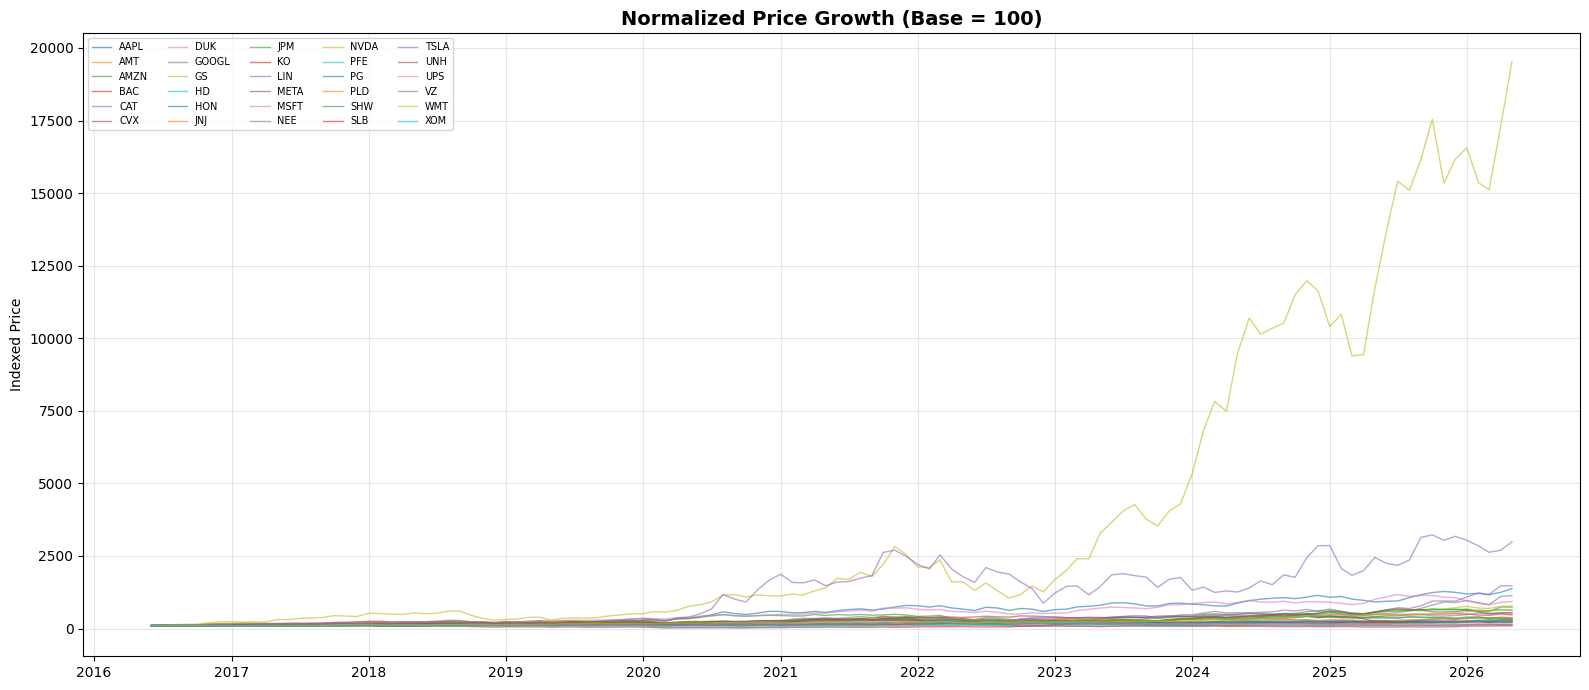

In [54]:
# === Normalized price growth (all assets indexed to 100) ===
normalized = (prices / prices.iloc[0]) * 100

fig, ax = plt.subplots(figsize=(16, 7))
for ticker in normalized.columns: 
    ax.plot(normalized.index, normalized[ticker], linewidth=1, alpha=0.6, label=ticker)

ax.set_title('Normalized Price Growth (Base = 100)', fontsize=14, fontweight='bold')
ax.set_ylabel('Indexed Price')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.legend(loc='upper left', ncol=5, fontsize=7)
plt.tight_layout()
plt.show()

In [56]:
# === Annualized return and volatility per asset ===
ann_return = returns.mean() * 12
ann_vol = returns.std() * np.sqrt(12)
sharpe = ann_return / ann_vol # Simplified Sharpe (no risk-free rate)

summary = pd.DataFrame({
    'Annualized Return': ann_return,
    'Annualized Vol': ann_vol, 
    'Sharpe (approx)': sharpe,
    'Sector': pd.Series(TICKER_SECTOR)
}).sort_values('Annualized Return', ascending=False).round(4)

print('Asset-level statistics (full 10-year window):')
summary

Asset-level statistics (full 10-year window):


,Annualized Return,Annualized Vol,Sharpe (approx),Sector
NVDA,0.6504,0.4688,1.3874,Information Technology
TSLA,0.5265,0.6330,0.8317,Consumer Discretionary
CAT,0.3204,0.3095,1.0350,Industrials
AAPL,0.3029,0.2690,1.1260,Information Technology
GOOGL,0.2828,0.2696,1.0491,Communication Services
GS,0.2498,0.2891,0.8642,Financials
AMZN,0.2488,0.3070,0.8105,Consumer Discretionary
MSFT,0.2478,0.2065,1.2001,Information Technology
META,0.2350,0.3550,0.6618,Communication Services
JPM,0.2151,0.2417,0.8899,Financials


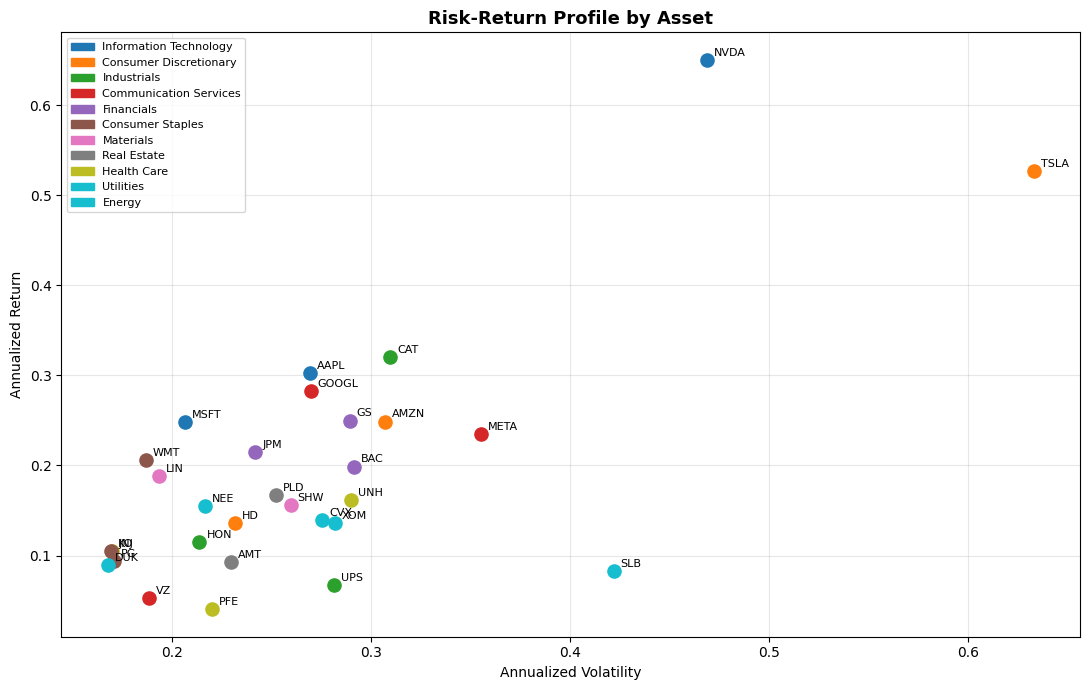

In [62]:
# === Risk-return scatter ===
fig, ax = plt.subplots(figsize=(11, 7))

sectors = summary['Sector'].unique()
palette = plt.cm.get_cmap('tab10', len(sectors))
color_map = {s: palette(i) for i, s in enumerate(sectors)}

for _, row in summary.iterrows():
    ax.scatter(row['Annualized Vol'], row['Annualized Return'],
               color=color_map[row['Sector']], s=90, zorder=3)
    ax.annotate(_, (row['Annualized Vol'], row['Annualized Return']),
               textcoords='offset points', xytext=(5, 3), fontsize=8)

# Legend
from matplotlib.patches import Patch
legend_handles = [Patch(color=color_map[s], label=s) for s in sectors]
ax.legend(handles=legend_handles, fontsize=8, loc='upper left')

ax.set_xlabel('Annualized Volatility')
ax.set_ylabel('Annualized Return')
ax.set_title('Risk-Return Profile by Asset', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

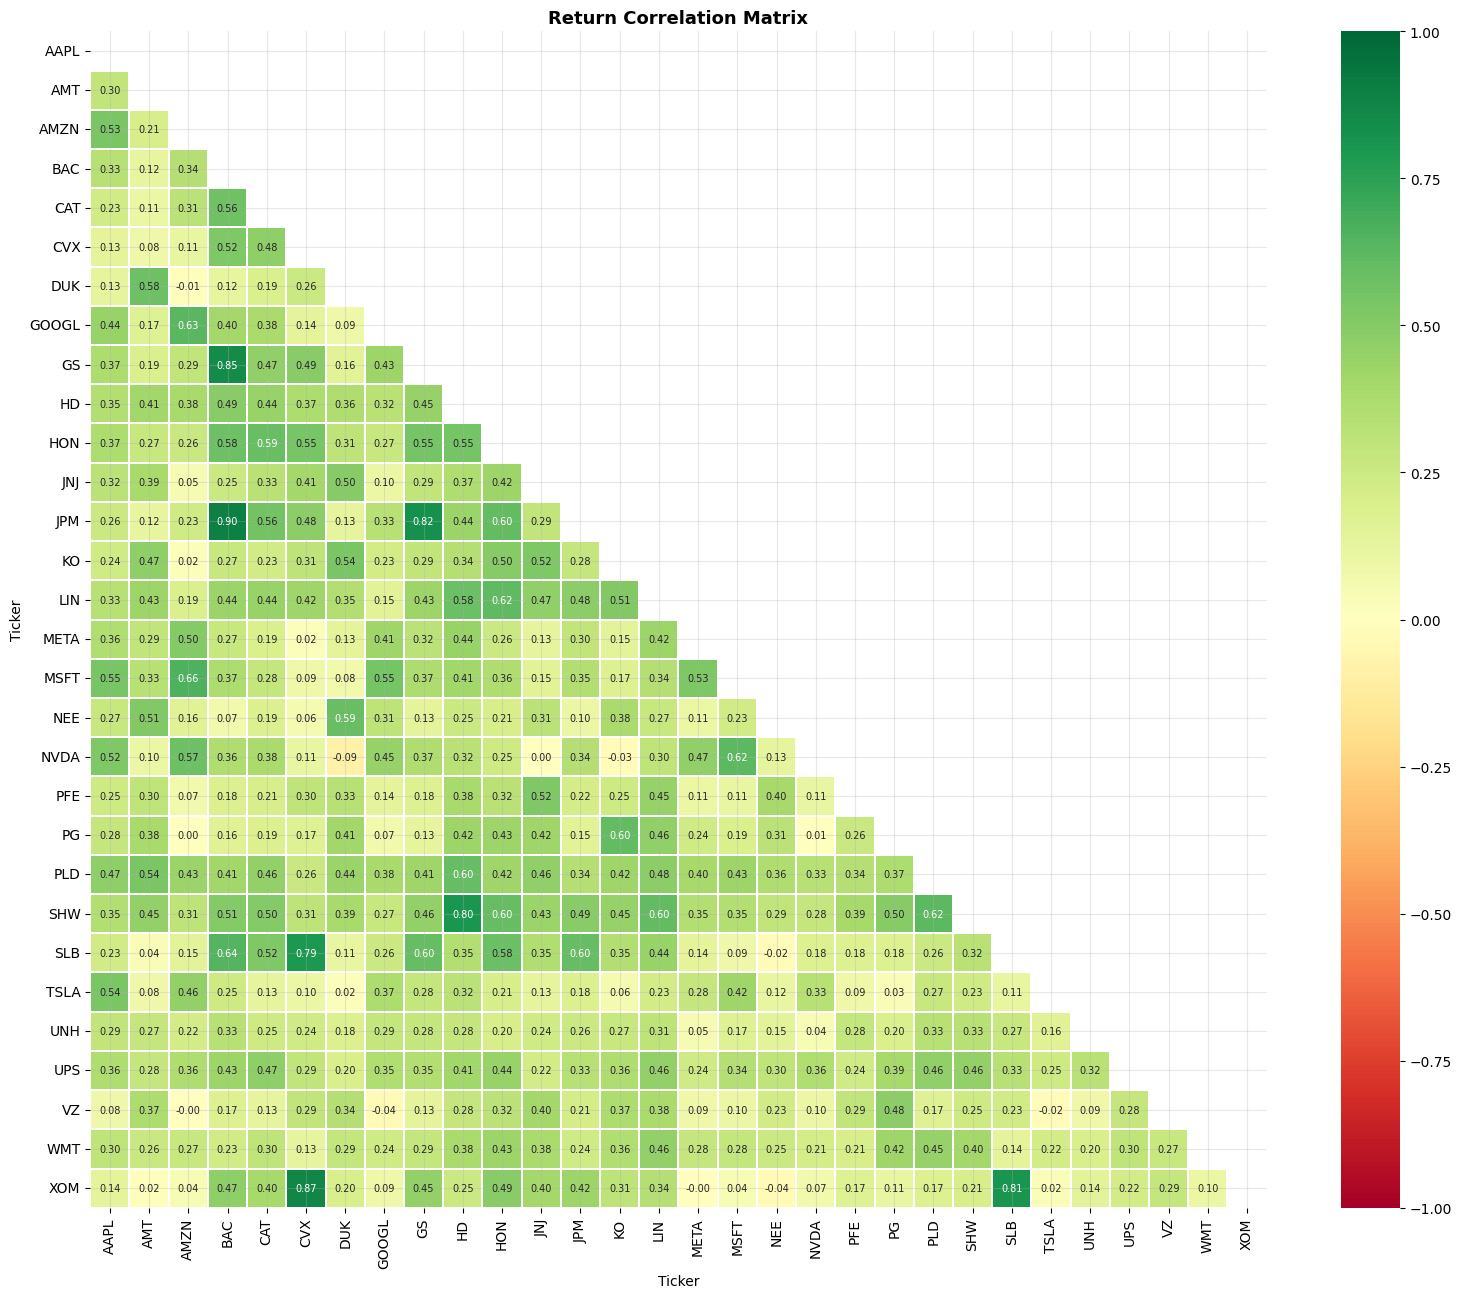

In [64]:
# === Correlation Heatmap ===
corr = returns.corr()

fig, ax = plt.subplots(figsize=(16, 13))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, vmin=-1, vmax=1, square=True, linewidths=0.3,
            annot_kws={'size': 7}, ax=ax)
ax.set_title('Return Correlation Matrix', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### Save Cleaned Data

In [67]:
os.makedirs('data', exist_ok=True)

prices.to_csv('data/prices_monthly.csv')
returns.to_csv('data/returns_monthly.csv')

# Save metadata
meta = pd.DataFrame({
    'ticker': list(TICKER_SECTOR.keys()),
    'sector': list(TICKER_SECTOR.values())
})
meta = meta[meta['ticker'].isin(prices.columns)]
meta.to_csv('data/ticker_metadata.csv', index=False)

# Save walk-forward config
config = {
    'train_months': TRAIN_MONTHS,
    'rebal_months': REBAL_MONTHS,
    'n_periods': n_periods, 
    'start_date': str(returns.index[0].date()),
    'end_date': str(returns.index[-1].date()),
    'n_assets': len(prices.columns)
}
pd.Series(config).to_json('data/config.json')

print('Saved:')
print(' data/prices_monthly.csv - adjusted monthly close prices')
print(' data/returns_monthly.csv - monthly simple returns')
print(' data/ticker_metadata.csv - ticker to sector mapping')
print(' data/config.json - walk-forward window config')

Saved:
 data/prices_monthly.csv - adjusted monthly close prices
 data/returns_monthly.csv - monthly simple returns
 data/ticker_metadata.csv - ticker to sector mapping
 data/config.json - walk-forward window config
